# Hauksson catalog → ETAS region polygon

1. Load the Hauksson ("haksson") catalog via `eq_mag_prediction.utilities.data_utils`
2. Plot with `catalog_tools` from `eq_mag_prediction.utilities.catalog_methods`
3. Build a region polygon for ETAS (`shape_coords` as `[[lat, lon], ...]`)

Region construction:
1. convex hull of catalog epicenters (keeps its vertex set)
2. move each of those vertices radially out from the centroid by `EXPAND_KM`
3. reconnect the moved vertices with straight edges (same number of vertices)


In [81]:
%matplotlib inline
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy import crs as ccrs
from IPython.display import display
from shapely.geometry import MultiPoint, Point, Polygon


def find_repo_root() -> Path:
    """Locate the etas repo root independent of kernel cwd."""
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code").is_dir() and (start / "etas").is_dir():
            return start
        if start.name == "notebooks" and (start.parent / "runnable_code").is_dir():
            return start.parent
    raise FileNotFoundError(
        "Could not find etas repo root. Set the kernel cwd to etas/ or etas/notebooks/."
    )


REPO_ROOT = find_repo_root()
print(f"REPO_ROOT = {REPO_ROOT}")

for _candidate in [
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction_clean",
    REPO_ROOT.parent / "eq_mag_prediction",
]:
    if (_candidate / "eq_mag_prediction").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

from eq_mag_prediction.utilities import data_utils
import eq_mag_prediction.utilities.catalog_methods  # noqa: F401 — registers .catalog_tools


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


REPO_ROOT = /home/neriberman/Repos/etas


## User config

In [82]:
pwd!


'/home/neriberman/Repos/etas'

In [83]:
# Optional magnitude floor for plotting / hull construction (None = all events).
MIN_MAGNITUDE = 2.5

# Move each hull vertex radially away from the polygon centroid by this many km.
EXPAND_KM = 100.0

# Where to write shape_coords .npy (ETAS expects [[lat, lon], ...]).
OUT_SHAPE_COORDS = REPO_ROOT / "input_data" / "hauksson_polygon_from_notebook.npy"


## Load Hauksson catalog

In [84]:
catalog = data_utils.hauksson_dataframe()
print(f"Loaded {len(catalog):,} events")
print(f"Columns: {list(catalog.columns)}")
print(
    f"time range (unix): {catalog.time.min():.0f} → {catalog.time.max():.0f}\n"
    f"magnitude: {catalog.magnitude.min():.2f} → {catalog.magnitude.max():.2f}\n"
    f"lon/lat: ({catalog.longitude.min():.3f}, {catalog.latitude.min():.3f})"
    f" → ({catalog.longitude.max():.3f}, {catalog.latitude.max():.3f})"
)
catalog.head()


Loaded 266,662 events
Columns: ['event_id', 'latitude', 'longitude', 'depth', 'magnitude', 'strike', 'dip', 'rake', 'time', 'x_utm', 'y_utm']
time range (unix): 347170435 → 1640993916
magnitude: -0.29 → 7.30
lon/lat: (-122.215, 30.861) → (-113.995, 38.541)


,event_id,latitude,longitude,depth,magnitude,strike,dip,rake,time,x_utm,y_utm
0,3301565,33.25517,-115.96750,5.68,2.26,318,57,-168,347170435.0,596175.343626,3.680051e+06
1,3301566,34.18600,-117.29733,6.49,2.37,0,49,-94,347174414.0,472602.164303,3.782820e+06
2,3301567,34.18433,-117.29600,6.75,1.60,326,55,-163,347175596.0,472724.181674,3.782634e+06
3,3301570,34.00633,-117.16200,15.35,1.88,348,70,-161,347185398.0,485040.753445,3.762870e+06
4,3301572,34.09367,-117.30517,16.46,1.40,210,61,-97,347194654.0,471849.133223,3.772584e+06


In [85]:
if MIN_MAGNITUDE is None:
    catalog_plot = catalog.copy()
else:
    catalog_plot = catalog.catalog_tools.filter_by_criteria(
        min_magnitude=MIN_MAGNITUDE,
        max_depth=np.inf,
    )
print(f"Events used for plots / polygon: {len(catalog_plot):,}")


Events used for plots / polygon: 26,973


## Plots (`catalog_tools`)

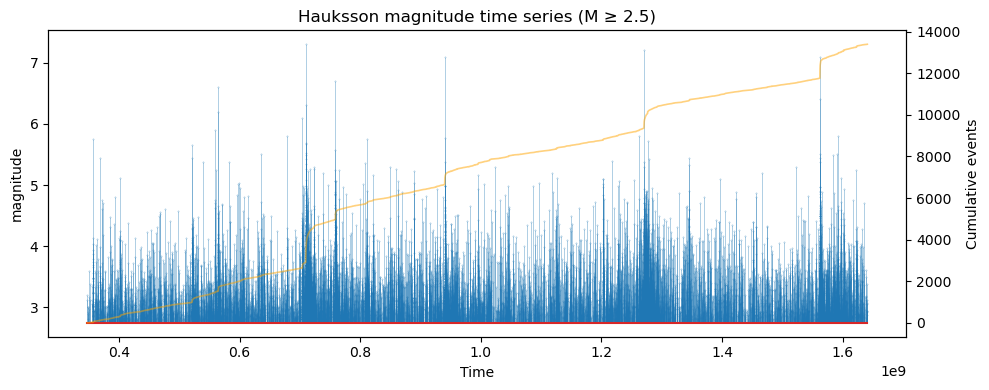

In [86]:
fig, ax = plt.subplots(figsize=(10, 4))
catalog_plot.catalog_tools.plot_time_series("magnitude", ax=ax)
ax.set_title(
    f"Hauksson magnitude time series"
    + (f" (M ≥ {MIN_MAGNITUDE})" if MIN_MAGNITUDE is not None else "")
)
fig.tight_layout()
show_fig(fig)


Setting extent: [-123.215   -113.60117   29.8615    39.43   ]


<Figure size 800x800 with 0 Axes>

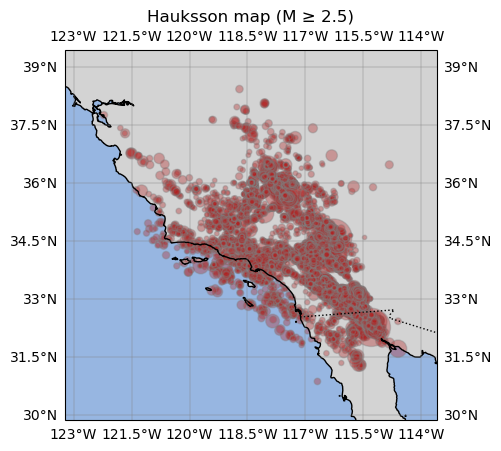

In [87]:
fig = plt.figure(figsize=(8, 8))
ax = catalog_plot.catalog_tools.plot_map(alpha=0.35, c="firebrick")
ax.set_title(
    f"Hauksson map"
    + (f" (M ≥ {MIN_MAGNITUDE})" if MIN_MAGNITUDE is not None else "")
)
show_fig(fig)


## Build ETAS polygon

ETAS inversion `shape_coords` are ordered **`[latitude, longitude]`** (not lon/lat).

Expansion is done in **California UTM meters** (`data_utils.california_projection`):
only the original hull vertices are shifted; edges are the straight segments between
consecutive shifted vertices (vertex count unchanged).


In [88]:
def hull_vertices_latlon(cat: pd.DataFrame) -> np.ndarray:
    """Convex-hull vertices as [[lat, lon], ...] (open ring, no closing repeat)."""
    pts = np.column_stack(
        [cat["latitude"].astype(float), cat["longitude"].astype(float)]
    )
    hull = MultiPoint(pts).convex_hull
    if isinstance(hull, Polygon):
        coords = np.asarray(hull.exterior.coords, dtype=float)[:-1]
    else:
        min_lat, min_lon = pts.min(axis=0)
        max_lat, max_lon = pts.max(axis=0)
        coords = np.array(
            [
                [min_lat, min_lon],
                [min_lat, max_lon],
                [max_lat, max_lon],
                [max_lat, min_lon],
            ],
            dtype=float,
        )
    if coords.shape[0] < 3:
        raise ValueError("Need at least 3 hull vertices.")
    return coords


def expand_vertices_from_center_km(
    vertices_latlon: np.ndarray,
    expand_km: float,
    *,
    projection=None,
) -> np.ndarray:
    """Move each vertex radially away from the centroid by expand_km.

    Returns an open [[lat, lon], ...] array with the same length / order.
    """
    if projection is None:
        projection = data_utils.california_projection()

    verts = np.asarray(vertices_latlon, dtype=float)
    if verts.ndim != 2 or verts.shape[1] != 2:
        raise ValueError("vertices_latlon must be shape (N, 2) as [lat, lon].")
    if expand_km == 0:
        return verts.copy()

    x, y = projection(verts[:, 1], verts[:, 0])
    xy = np.column_stack([np.asarray(x, dtype=float), np.asarray(y, dtype=float)])

    center = xy.mean(axis=0)
    vec = xy - center
    dist = np.linalg.norm(vec, axis=1)
    if np.any(dist <= 0):
        raise ValueError("A hull vertex coincides with the center; cannot expand radially.")

    xy_out = xy + (vec / dist[:, None]) * (expand_km * 1000.0)
    lon_out, lat_out = projection(xy_out[:, 0], xy_out[:, 1], inverse=True)
    return np.column_stack([np.asarray(lat_out, dtype=float), np.asarray(lon_out, dtype=float)])


def close_ring(vertices_latlon: np.ndarray) -> np.ndarray:
    """Append the first vertex so ETAS / plotting get a closed ring."""
    v = np.asarray(vertices_latlon, dtype=float)
    return np.vstack([v, v[0]])


def ring_as_polygon(vertices_latlon_closed: np.ndarray) -> Polygon:
    """Plot / distance helper only — does not alter the saved vertex list."""
    return Polygon(np.asarray(vertices_latlon_closed, dtype=float))


def min_event_distance_to_boundary_km(
    cat: pd.DataFrame,
    poly_latlon: Polygon,
    *,
    projection=None,
) -> float:
    """Minimum distance (km) from any event to the polygon exterior."""
    if projection is None:
        projection = data_utils.california_projection()

    latlon = np.asarray(poly_latlon.exterior.coords, dtype=float)
    x, y = projection(latlon[:, 1], latlon[:, 0])
    boundary_xy = Polygon(np.column_stack([x, y])).exterior

    ev_x, ev_y = projection(
        cat["longitude"].astype(float).to_numpy(),
        cat["latitude"].astype(float).to_numpy(),
    )
    dists_m = [boundary_xy.distance(Point(float(xx), float(yy))) for xx, yy in zip(ev_x, ev_y)]
    return float(np.min(dists_m) / 1000.0)


proj = data_utils.california_projection()
hull_verts = hull_vertices_latlon(catalog_plot)  # open ring
expanded_verts = expand_vertices_from_center_km(hull_verts, EXPAND_KM, projection=proj)
assert expanded_verts.shape == hull_verts.shape, (
    f"Vertex count changed: {hull_verts.shape} → {expanded_verts.shape}"
)

# Closed rings for plotting / shapely helpers; shape_coords keeps the same verts.
hull_closed = close_ring(hull_verts)
shape_coords = close_ring(expanded_verts)
hull = ring_as_polygon(hull_closed)
etas_polygon = ring_as_polygon(shape_coords)

print(f"event hull verts: {len(hull_verts)}")
print(f"expanded verts:   {len(expanded_verts)}  (must match)")

min_dist_km = min_event_distance_to_boundary_km(catalog_plot, etas_polygon, projection=proj)
print(f"\nMin event→boundary distance: {min_dist_km:.2f} km")
print(f"EXPAND_KM (radial):            {EXPAND_KM:.2f} km")
print(f"\nshape_coords shape: {shape_coords.shape}  (columns = lat, lon; closed)")
shape_coords[:5]


event hull verts: 9
expanded verts:   9  (must match)



Min event→boundary distance: 56.65 km
EXPAND_KM (radial):            100.00 km

shape_coords shape: (10, 2)  (columns = lat, lon; closed)


array([[  38.35559062, -123.062567  ],
       [  34.87362339, -122.43163314],
       [  33.69809998, -121.39278858],
       [  29.98162473, -116.45704659],
       [  30.4543598 , -115.07193907]])

Setting extent: [-123.215   -113.60117   29.8615    39.43   ]


<Figure size 800x800 with 0 Axes>

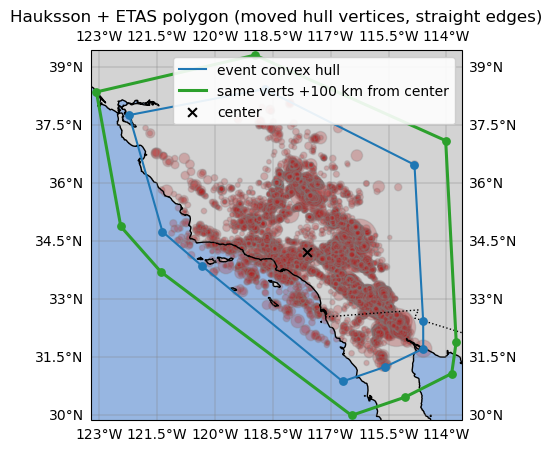

In [89]:
def plot_poly_vertices(
    ax,
    vertices_latlon_closed: np.ndarray,
    *,
    color: str,
    label: str,
    lw: float = 1.5,
    mark_vertices: bool = True,
):
    # vertices are [lat, lon]; cartopy expects (lon, lat)
    coords = np.asarray(vertices_latlon_closed, dtype=float)
    lats, lons = coords[:, 0], coords[:, 1]
    ax.plot(
        lons,
        lats,
        transform=ccrs.PlateCarree(),
        color=color,
        linewidth=lw,
        label=label,
    )
    if mark_vertices:
        ax.scatter(
            lons[:-1],
            lats[:-1],
            transform=ccrs.PlateCarree(),
            c=color,
            s=28,
            zorder=4,
        )


fig = plt.figure(figsize=(8, 8))
ax = catalog_plot.catalog_tools.plot_map(alpha=0.25, c="firebrick")
plot_poly_vertices(ax, hull_closed, color="tab:blue", label="event convex hull")
plot_poly_vertices(
    ax,
    shape_coords,
    color="tab:green",
    label=f"same verts +{EXPAND_KM:g} km from center",
    lw=2.2,
)

# Centroid of original hull vertices (UTM mean, same as expansion center)
hx, hy = proj(hull_verts[:, 1], hull_verts[:, 0])
center = np.column_stack([np.asarray(hx, dtype=float), np.asarray(hy, dtype=float)]).mean(axis=0)
clon, clat = proj(center[0], center[1], inverse=True)
ax.scatter(
    [clon], [clat],
    transform=ccrs.PlateCarree(),
    c="black", s=40, marker="x", zorder=5, label="center",
)

ax.legend(loc="upper right", framealpha=0.9)
ax.set_title("Hauksson + ETAS polygon (moved hull vertices, straight edges)")
show_fig(fig)


## Save polygon for ETAS

Point config `shape_coords` at the saved `.npy`, e.g.
`"shape_coords": "input_data/hauksson_polygon_from_notebook.npy"`.

In [90]:
OUT_SHAPE_COORDS


PosixPath('/home/neriberman/Repos/etas/input_data/hauksson_polygon_from_notebook.npy')

In [91]:
OUT_SHAPE_COORDS.parent.mkdir(parents=True, exist_ok=True)
np.save(OUT_SHAPE_COORDS, shape_coords)
print(f"Wrote {OUT_SHAPE_COORDS}")
print(f"  relative to repo: {OUT_SHAPE_COORDS.relative_to(REPO_ROOT)}")

# Quick reload check
reloaded = np.load(OUT_SHAPE_COORDS)
assert reloaded.shape == shape_coords.shape
assert np.allclose(reloaded, shape_coords)
print("Reload OK.")


Wrote /home/neriberman/Repos/etas/input_data/hauksson_polygon_from_notebook.npy
  relative to repo: input_data/hauksson_polygon_from_notebook.npy
Reload OK.


## Optional: filter catalog to the selected polygon

`catalog_tools.filter_catalog_by_polygon` expects longitude / latitude vertex lists.

In [92]:
lon_ring = shape_coords[:, 1]
lat_ring = shape_coords[:, 0]
inside = catalog_plot.catalog_tools.filter_catalog_by_polygon(lon_ring, lat_ring)
print(
    f"Events inside selected polygon: {len(inside):,} / {len(catalog_plot):,} "
    f"({100 * len(inside) / max(len(catalog_plot), 1):.1f}%)"
)
inside.head()


Events inside selected polygon: 26,973 / 26,973 (100.0%)


,event_id,latitude,longitude,depth,magnitude,strike,dip,rake,time,x_utm,y_utm
0,3301609,36.05567,-118.29083,10.07,3.13,59,72,-85,347295789.0,383739.333961,3.990894e+06
1,3301639,32.16083,-115.78917,17.97,2.77,69,54,-119,347448092.0,614172.987651,3.558905e+06
2,3301757,33.92983,-118.68083,8.59,3.20,124,30,126,347813534.0,344643.010352,3.755648e+06
3,3301864,34.19100,-117.24483,3.90,2.58,278,62,-172,348098533.0,477441.184203,3.783361e+06
4,3301868,34.19267,-117.24550,4.08,2.54,276,66,-172,348100143.0,477379.895652,3.783546e+06
